In [1]:
import pandas as pd
from supabase import create_client, Client
import os
from dotenv import load_dotenv
import seaborn as sns
import matplotlib.pyplot as plt

load_dotenv()

url = os.getenv('SUPABASE_URL')
key = os.getenv('SUPABASE_KEY')
supabase = create_client(supabase_url=url, supabase_key=key)

In [6]:
response = (
    supabase.table("logs")
    .select("*")
    # .gt("created_at", ["2025-05-28T20:02:21+0000"])
    .eq("client_name", "hinze_rmp_summer_2025")
    .eq("api_endpoint", "/score/summary/stairs")
    .execute()
)
data = response.data

In [7]:
df1 = pd.DataFrame(data)
df2 = pd.json_normalize(df1["request_body"])
df3 = pd.json_normalize(df1["response_body"])
df = pd.concat([
    df1,
    df2,
    df3
], axis=1)
# Drop columns that start with "focus_time"
df = df.loc[:, ~df.columns.str.startswith('focus_time')]
# Select rows with class_id == "hinze_class"
df = df.query("class_id == 'hinze_class'")
df['created_at'] = pd.to_datetime(df['created_at'])
df = df.set_index('created_at')
with pd.option_context('display.max_columns', None): 
    display(df.sample(5))

,id,api_endpoint,request_method,status_code,client_name,request_body,response_body,ttft,process_time,summary,class_id,page_slug,chat_history,score_history,excluded_chunks,prompt,is_passed,metrics.content.name,metrics.content.score,metrics.content.feedback,metrics.content.is_passed,metrics.content.threshold,metrics.english.name,metrics.english.score,metrics.english.feedback,metrics.english.is_passed,metrics.english.threshold,metrics.profanity.name,metrics.profanity.score,metrics.profanity.feedback,metrics.profanity.is_passed,metrics.profanity.threshold,metrics.similarity.name,metrics.similarity.score,metrics.similarity.feedback,metrics.similarity.is_passed,metrics.similarity.threshold,metrics.containment.name,metrics.containment.score,metrics.containment.feedback,metrics.containment.is_passed,metrics.containment.threshold,metrics.containment_chat.name,metrics.containment_chat.score,metrics.containment_chat.feedback,metrics.containment_chat.is_passed,metrics.containment_chat.threshold,text,chunk,request_id,question_type
created_at,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2025-06-02 22:43:51.747215+00:00,27022,/score/summary/stairs,POST,200,hinze_rmp_summer_2025,{'summary': 'This page is about how researches...,{'prompt': 'Excellent job summarizing the text...,NaN,4.393936,This page is about how researches are studying...,hinze_class,7-a-model-of-scientific-research-in-psychology,[],"[0.457797199487686, 0.105166874825954, -0.0804...",[Cell-Phones-and-Driving-1496t],Excellent job summarizing the text. Please mov...,True,Content,0.391899,You did a good job of including key ideas and ...,True,-0.029202,English,1.0,,True,1.0,Profanity,0.0,,True,0.0,Relevance,0.864104,You did a good job of staying on topic and wri...,True,0.5,Language Borrowing,0.0690,You did a good job of using your own language ...,True,0.6,Language Borrowing (from iTELL AI),NaN,None,None,0.6,NaN,NaN,NaN,NaN
2025-06-04 03:23:08.192810+00:00,27280,/score/summary/stairs,POST,200,hinze_rmp_summer_2025,{'summary': 'This page is about moral foundati...,{'prompt': 'Excellent job summarizing the text...,NaN,4.897260,This page is about moral foundations and ethic...,hinze_class,15-moral-foundations-of-ethical-research,[],"[0.309789061546326, 0.361861765384674, 0.57512...",[A-Framework-for-Thinking-About-Research-Ethic...,Excellent job summarizing the text. Please mov...,True,Content,0.324373,You did a good job of including key ideas and ...,True,0.113651,English,1.0,,True,1.0,Profanity,0.0,,True,0.0,Relevance,0.862464,You did a good job of staying on topic and wri...,True,0.5,Language Borrowing,0.0000,You did a good job of using your own language ...,True,0.6,Language Borrowing (from iTELL AI),NaN,None,None,0.6,NaN,NaN,NaN,NaN
2025-06-10 17:02:49.790811+00:00,27935,/score/summary/stairs,POST,200,hinze_rmp_summer_2025,{'summary': 'This page is about psychological ...,{'prompt': 'Excellent job summarizing the text...,NaN,10.548773,This page is about psychological measurements....,hinze_class,understanding-psychological-measures,[],"[1.00666487216949, 0.477541506290436, 0.500475...","[Psychological-Constructs-1658t, Levels-of-Mea...",Excellent job summarizing the text. Please mov...,True,Content,0.801071,You did a good job of including key ideas and ...,True,0.275868,English,1.0,,True,1.0,Profanity,0.0,,True,0.0,Relevance,0.896448,You did a good job of staying on topic and wri...,True,0.5,Language Borrowing,0.0494,You did a good job of using your own language ...,True,0.6,Language Borrowing (from iTELL AI),NaN,None,None,0.6,NaN,NaN,NaN,NaN
2025-06-04 01:08:37.617043+00:00,27199,/score/summary/stairs,POST,200,hinze_rmp_summer_2025,{'summary': 'This page is about how come with ...,{'prompt': 'Excellent job summarizing the text...,NaN,6.466822,This page is about how come with different emp...,hinze_class,9-generating-good-research-questions,[],"[0.440040826797485, 0.0376236848533154, 0.0224...",[Interestingness-1539t],Excellent job summarizing the text. Please mov...,Tr

In [8]:
df.class_id

created_at
2025-05-30 02:27:38.537215+00:00    hinze_class
2025-05-30 17:38:50.579439+00:00    hinze_class
2025-05-30 22:15:11.067578+00:00    hinze_class
2025-05-30 23:11:18.756226+00:00    hinze_class
2025-05-31 21:45:51.990229+00:00    hinze_class
                                       ...     
2025-06-10 05:17:04.937862+00:00    hinze_class
2025-06-10 17:02:49.790811+00:00    hinze_class
2025-06-10 18:59:41.850749+00:00    hinze_class
2025-06-11 00:19:07.221370+00:00    hinze_class
2025-06-11 03:04:56.456876+00:00    hinze_class
Name: class_id, Length: 62, dtype: object

In [9]:
df["is_passed"].astype(int).describe()

count    62.000000
mean      0.919355
std       0.274512
min       0.000000
25%       1.000000
50%       1.000000
75%       1.000000
max       1.000000
Name: is_passed, dtype: float64

In [10]:
(
    df[["metrics.content.score", "metrics.content.threshold"]]
    .rename(columns={
        "metrics.content.score": "score",
        "metrics.content.threshold": "threshold",
    })
    .query("score.notna()")
    .assign(
        score_gt_threshold = lambda x: 
        (x["score"] > x["threshold"]).astype(int)
    ).describe()
)

,score,threshold,score_gt_threshold
count,58.000000,58.000000,58.000000
mean,0.516248,0.092318,0.982759
std,0.192083,0.130126,0.131306
min,0.022408,-0.218191,0.000000
25%,0.406289,0.011592,1.000000
50%,0.560807,0.076741,1.000000
75%,0.643891,0.146086,1.000000
max,0.956090,0.361535,1.000000


<Axes: xlabel='created_at', ylabel='metrics.content.score'>

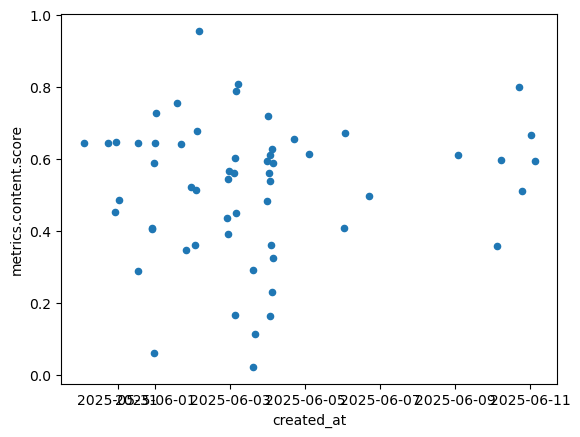

In [11]:
df.reset_index().plot.scatter(x="created_at", y="metrics.content.score")

In [12]:
df

,id,api_endpoint,request_method,status_code,client_name,request_body,response_body,ttft,process_time,summary,...,metrics.containment.threshold,metrics.containment_chat.name,metrics.containment_chat.score,metrics.containment_chat.feedback,metrics.containment_chat.is_passed,metrics.containment_chat.threshold,text,chunk,request_id,question_type
created_at,,,,,,,,,,,,,,,,,,,,,
2025-05-30 02:27:38.537215+00:00,26742,/score/summary/stairs,POST,200,hinze_rmp_summer_2025,{'summary': 'This page outlines a framework fo...,{'prompt': 'Excellent job summarizing the text...,NaN,5.605550,This page outlines a framework for research et...,...,0.6,Language Borrowing (from iTELL AI),NaN,None,None,0.6,NaN,NaN,NaN,NaN
2025-05-30 17:38:50.579439+00:00,26762,/score/summary/stairs,POST,200,hinze_rmp_summer_2025,{'summary': 'This page outlines a framework fo...,{'prompt': 'Excellent job summarizing the text...,NaN,8.479198,This page outlines a framework for research et...,...,0.6,Language Borrowing (from iTELL AI),NaN,None,None,0.6,NaN,NaN,NaN,NaN
2025-05-30 22:15:11.067578+00:00,26765,/score/summary/stairs,POST,200,hinze_rmp_summer_2025,{'summary': 'This page discusses a model of sc...,{'prompt': 'Excellent job summarizing the text...,NaN,3.615358,This page discusses a model of scientific rese...,...,0.6,Language Borrowing (from iTELL AI),NaN,None,None,0.6,NaN,NaN,NaN,NaN
2025-05-30 23:11:18.756226+00:00,26780,/score/summary/stairs,POST,200,hinze_rmp_summer_2025,{'summary': 'This page is about finding a rese...,{'prompt': 'Excellent job summarizing the text...,NaN,9.555500,This page is about finding a research topic. G...,...,0.6,Language Borrowing (from iTELL AI),NaN,None,None,0.6,NaN,NaN,NaN,NaN
2025-05-31 21:45:51.990229+00:00,26802,/score/summary/stairs,POST,200,hinze_rmp_summer_2025,{'summary': 'When conducting scientific resear...,{'prompt': 'Excellent job summarizing the text...,NaN,7.802234,When conducting scientific research in psychol...,...,0.6,Language Borrowing (from iTELL AI),NaN,None,None,0.6,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-10 05:17:04.937862+00:00,27914,/score/summary/stairs,POST,200,hinze_rmp_summer_2025,"{'summary': 'Psychological measurement, it beg...",{'prompt': 'Excellent job summarizing the text...,NaN,6.485993,"Psychological measurement, it begins with disc...",...,0.6,Language Borrowing (from iTELL AI),NaN,None,None,0.6,NaN,NaN,NaN,NaN
2025-06-10 17:02:49.790811+00:00,27935,/score/summary/stairs,POST,200,hinze_rmp_summer_2025,{'summary': 'This page is about psychological ...,{'prompt': 'Excellent job summarizing the text...,NaN,10.548773,This page is about psychological measurements....,...,0.6,Language Borrowing (from iTELL AI),NaN,None,None,0.6,NaN,NaN,NaN,NaN
2025-06-10 18:59:41.850749+00:00,27944,/score/summary/stairs,POST,200,hinze_rmp_summer_2025,"{'summary': 'This page is about measurement, p...",{'prompt': 'Excellent job summarizing the text...,NaN,7.955651,"This page is about measurement, psychometrics ...",...,0.6,Language Borrowing (from iTELL AI),NaN,None,None,0.6,NaN,NaN,NaN,NaN


<Figure size 1200x600 with 0 Axes>

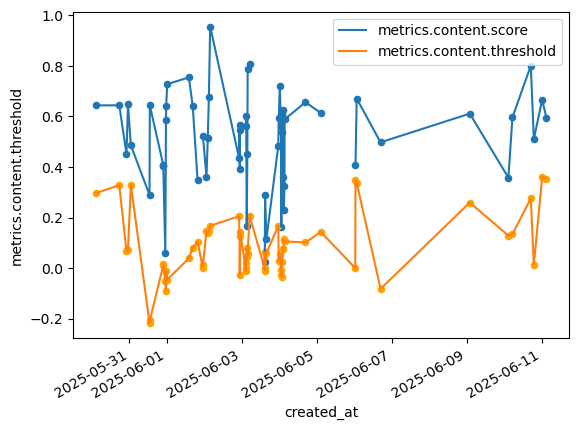

In [13]:
plt.figure(figsize=(12, 6))
ax = df.reset_index().plot.scatter(x="created_at", y="metrics.content.score")
df.reset_index().plot.scatter(x="created_at", y="metrics.content.threshold", ax=ax, c="orange")
df["metrics.content.score"].plot()  
df["metrics.content.threshold"].plot()

plt.legend()
plt.show();

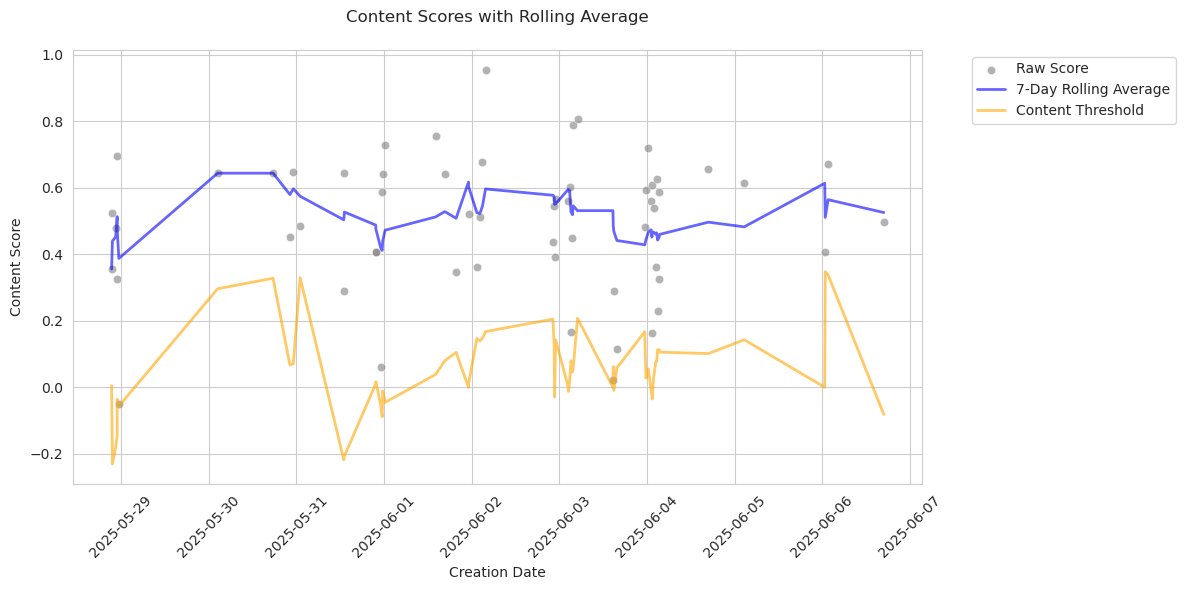

In [9]:
df = df.sort_values('created_at')

# Set the style
sns.set_style("whitegrid")
plt.figure(figsize=(12, 6))

# Create the main line plot
sns.scatterplot(data=df, x='created_at', y='metrics.content.score', 
             label='Raw Score', alpha=0.6, color='gray')

# Calculate and plot rolling average (7-day window)
rolling_avg = df['metrics.content.score'].rolling(window="1D", min_periods=1).mean()
sns.lineplot(x=df.index, y=rolling_avg, 
             label='7-Day Rolling Average', 
             color='blue', linewidth=2, alpha=0.6)

# Draw Threshold
sns.lineplot(data=df, x='created_at', y='metrics.content.threshold', 
             label='Content Threshold', 
             color='orange', linewidth=2, alpha=0.6)

# Customize the plot
plt.title('Content Scores with Rolling Average', pad=20)
plt.xlabel('Creation Date')
plt.ylabel('Content Score')

# Rotate x-axis labels
plt.xticks(rotation=45)

# # Indicate when we started dynamic scoring
# implementation_date = pd.to_datetime("2024-11-13 05:17:11.410141+00")
# plt.axvline(
#     implementation_date,
#     color="red",
#     linestyle="--",
#     label="Implemented Dynamic Scoring"
# )

# Add legend
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Adjust layout to prevent label cutoff
plt.tight_layout()

plt.show()

In [14]:
df = df.sort_values('created_at')

# Set the style
sns.set_style("whitegrid")
plt.figure(figsize=(12, 6))

# Create the main line plot
sns.scatterplot(data=df, x='created_at', y='content', 
             label='Raw Score', alpha=0.6, color='gray')

# Calculate and plot rolling average (7-day window)
rolling_avg = df['content'].rolling(window="7D", min_periods=1).mean()
sns.lineplot(x=df.index, y=rolling_avg, 
             label='7-Day Rolling Average', 
             color='blue', linewidth=2, alpha=0.6)

# Draw Threshold
sns.lineplot(data=df.loc[(df.score_history.str.len() == 0)], x='created_at', y='metrics.content.threshold', 
             label='Content Threshold', 
             color='green', linewidth=1, alpha=1)

# Customize the plot
plt.title('Content Scores with Rolling Average', pad=20)
plt.xlabel('Creation Date')
plt.ylabel('Content Score')

# Rotate x-axis labels
plt.xticks(rotation=45)

# Indicate when we started dynamic scoring
implementation_date = pd.to_datetime("2024-11-13 05:17:11.410141+00")
plt.axvline(
    implementation_date,
    color="red",
    linestyle="--",
    label="Implemented Dynamic Scoring"
)

# Add legend
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Adjust layout to prevent label cutoff
plt.tight_layout()

plt.show()

ValueError: Could not interpret value `content` for `y`. An entry with this name does not appear in `data`.

<Figure size 1200x600 with 0 Axes>

In [9]:
(df.content < df["metrics.content.threshold"]).loc[
    df.index >= pd.to_datetime("2025-01-01 05:17:11.410141+00")
].describe()

count       169
unique        2
top       False
freq        154
dtype: object

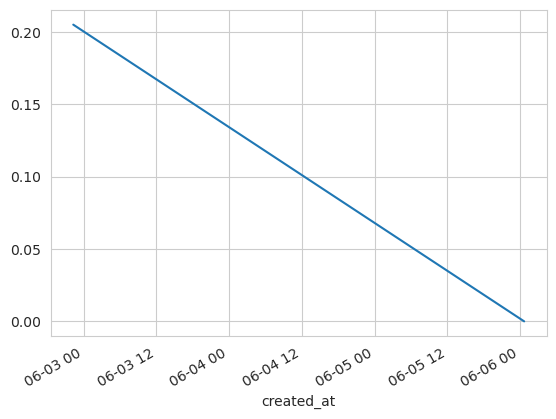

In [16]:
df_no_score_history = df.loc[
    (df.score_history.str.len() == 0)
    # & (df.index >= pd.to_datetime("2024-11-13 05:17:11.410141+00"))
]
df_no_score_history["metrics.content.threshold"].plot();

In [18]:
df.score_history

created_at
2025-05-30 02:27:38.537215+00:00    [0.875017106533051, 0.692004203796387, 0.58298...
2025-05-30 17:38:50.579439+00:00    [0.875017106533051, 0.692004203796387, 0.58298...
2025-05-30 22:15:11.067578+00:00    [1.00666487216949, 0.477541506290436, 0.500475...
2025-05-30 23:11:18.756226+00:00    [1.00666487216949, 0.477541506290436, 0.500475...
2025-05-31 01:02:55.593312+00:00    [0.721329689025879, 0.43935614824295, 0.532722...
                                                          ...                        
2025-06-10 05:17:04.937862+00:00    [0.540430009365082, 0.248934119939804, 0.43569...
2025-06-10 17:02:49.790811+00:00    [1.00666487216949, 0.477541506290436, 0.500475...
2025-06-10 18:59:41.850749+00:00    [0.26247775554657, 0.190999522805214, 0.062140...
2025-06-11 00:19:07.221370+00:00    [0.435904204845428, 0.544590532779694, 0.56547...
2025-06-11 03:04:56.456876+00:00    [0.655279397964478, 0.655279397964478, 0.44090...
Name: score_history, Length: 62, dtype: obj